# Draft Notebook (MobileNetV2)



##  Imports & Setup 

In [1]:
import  time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim


from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import (classification_report, confusion_matrix,roc_curve, auc, f1_score)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
root= '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'
save_dir = '/kaggle/working'

print(f'Device: {device}')

Device: cuda


## Preprocessing 

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

train_set = datasets.ImageFolder(root=f'{root}/train', transform=train_transform)
val_set   = datasets.ImageFolder(root=f'{root}/valid', transform=val_transform)
test_set  = datasets.ImageFolder(root=f'{root}/test',  transform=val_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader= DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)
print('Classes:', train_set.class_to_idx)
print(f'Train:{len(train_set):,} images')
print(f'Validation: {len(val_set):,} images')
print(f'Test:{len(test_set):,} images')

Classes: {'fake': 0, 'real': 1}
Train:100,000 images
Validation: 20,000 images
Test:20,000 images


## Cell 3 — Model Definition
> ⚠️ **This is the ONLY cell that changes between draft notebooks**
>
> Change the 3 lines marked with `# ← CHANGE THIS`

In [3]:
MODEL_NAME = 'MobileNetV2'                           
def build_model():
    model = models.mobilenet_v2(weights='IMAGENET1K_V1')
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
    return model
model  = build_model().to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: {MODEL_NAME} | Parameters: {params/1e6:.1f}M')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 154MB/s]


Model: MobileNetV2 | Parameters: 2.2M


## Cell 4 — Experiment 1: Learning Rate Finder
Find the best learning rate scientifically instead of guessing.

/usr/local/lib/python3.12/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 4.98E-04


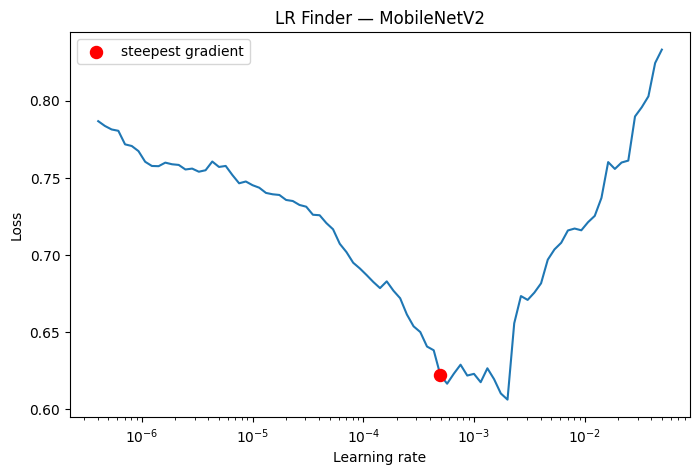

In [4]:
!pip install torch-lr-finder --quiet
from torch_lr_finder import LRFinder

# Reset model to fresh weights for a clean test
model_lr = build_model().to(device)
optimizer_lr = optim.Adam(model_lr.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

lr_finder = LRFinder(model_lr, optimizer_lr, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=0.1, num_iter=100)

fig, ax = plt.subplots(figsize=(8, 5))
lr_finder.plot(ax=ax)
ax.set_title(f'LR Finder — {MODEL_NAME}')
plt.savefig(f'{save_dir}/lr_finder_{MODEL_NAME}.png')
plt.show()
lr_finder.reset()

## Cell 5 — Experiment 2: Compare 3 Learning Rates
Train for 3 epochs each with LR = 1e-3, 1e-4, 1e-5. Pick the best.


Testing LR = 0.001
  Epoch 1 | Val acc: 96.15%
  Epoch 2 | Val acc: 97.78%
  Epoch 3 | Val acc: 98.09%

Testing LR = 0.0001
  Epoch 1 | Val acc: 99.33%
  Epoch 2 | Val acc: 99.44%
  Epoch 3 | Val acc: 99.59%

Testing LR = 1e-05
  Epoch 1 | Val acc: 96.67%
  Epoch 2 | Val acc: 98.54%
  Epoch 3 | Val acc: 98.88%


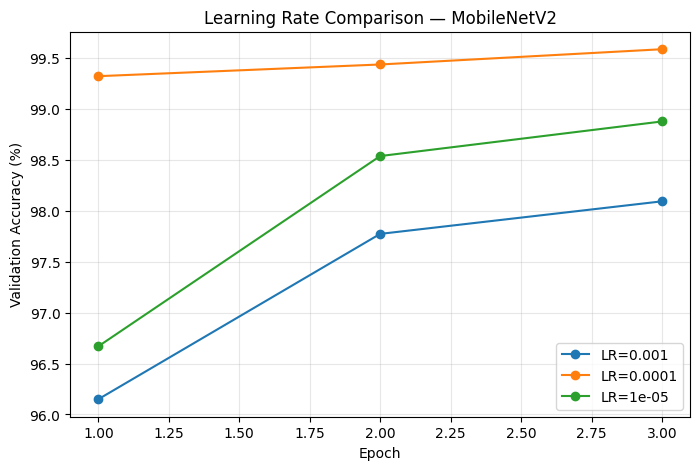


Best LR forMobileNetV2: 0.0001


In [5]:
criterion  = nn.CrossEntropyLoss()
lr_results = {}

for lr in [1e-3, 1e-4, 1e-5]:
    print(f'\nTesting LR = {lr}')
    m   = build_model().to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    val_accs = []

    for epoch in range(3):  # 3 epochs is enough to compare
        # Training
        m.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            loss = criterion(m(imgs), lbls)
            loss.backward()
            opt.step()

        # Validation
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = m(imgs).argmax(dim=1)
                correct += (preds == lbls).sum().item()
                total   += lbls.size(0)
        acc = correct / total * 100
        val_accs.append(acc)
        print(f'  Epoch {epoch+1} | Val acc: {acc:.2f}%')

    lr_results[lr] = val_accs

# Plot comparison
plt.figure(figsize=(8, 5))
for lr, accs in lr_results.items():
    plt.plot(range(1, 4), accs, marker='o', label=f'LR={lr}')
plt.title(f'Learning Rate Comparison — {MODEL_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{save_dir}/lr_comparison_{MODEL_NAME}.png')
plt.show()

best_lr = max(lr_results, key=lambda lr: max(lr_results[lr]))
print(f'\nBest LR for{MODEL_NAME}: {best_lr}')

## Cell 7 — Full Training with Best Settings
Using the best LR and strategy found above — train for 10 epochs.

In [6]:
BEST_LR = best_lr 
EPOCHS  = 10

model     = build_model().to(device)
optimizer = optim.Adam(model.parameters(), lr=BEST_LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss()

history      = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0
save_path    = f'{save_dir}/best_{MODEL_NAME}.pth'

print(f'Training {MODEL_NAME} with LR={BEST_LR} for {EPOCHS} epochs')
print('='*60)

start = time.time()
for epoch in range(EPOCHS):
    t0 = time.time()

    # Training
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item()
        tr_correct += (out.argmax(1) == lbls).sum().item()
        tr_total   += lbls.size(0)

    tr_loss /= len(train_loader)
    tr_acc   = tr_correct / tr_total * 100

    # Validation
    model.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out  = model(imgs)
            loss = criterion(out, lbls)
            vl_loss    += loss.item()
            vl_correct += (out.argmax(1) == lbls).sum().item()
            vl_total   += lbls.size(0)

    vl_loss /= len(val_loader)
    vl_acc   = vl_correct / vl_total * 100
    scheduler.step(vl_loss)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), save_path)
        saved = 'saved'
    else:
        saved = ''

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train loss: {tr_loss:.4f} acc: {tr_acc:.2f}% | '
          f'Val loss: {vl_loss:.4f} acc: {vl_acc:.2f}% | '
          f'{time.time()-t0:.0f}s {saved}')

total_time = time.time() - start
print(f'\nDone! Best val acc: {best_val_acc:.2f}% | Total: {total_time/60:.1f} min')

Training MobileNetV2 with LR=0.0001 for 10 epochs
Epoch 01/10 | Train loss: 0.1154 acc: 95.35% | Val loss: 0.0231 acc: 99.13% | 476s saved
Epoch 02/10 | Train loss: 0.0432 acc: 98.43% | Val loss: 0.0207 acc: 99.27% | 463s saved
Epoch 03/10 | Train loss: 0.0284 acc: 98.95% | Val loss: 0.0215 acc: 99.19% | 467s 
Epoch 04/10 | Train loss: 0.0229 acc: 99.18% | Val loss: 0.0136 acc: 99.52% | 465s saved
Epoch 05/10 | Train loss: 0.0187 acc: 99.33% | Val loss: 0.0086 acc: 99.70% | 465s saved
Epoch 06/10 | Train loss: 0.0154 acc: 99.44% | Val loss: 0.0063 acc: 99.78% | 464s saved
Epoch 07/10 | Train loss: 0.0133 acc: 99.52% | Val loss: 0.0079 acc: 99.72% | 463s 
Epoch 08/10 | Train loss: 0.0125 acc: 99.57% | Val loss: 0.0048 acc: 99.84% | 461s saved
Epoch 09/10 | Train loss: 0.0113 acc: 99.61% | Val loss: 0.0074 acc: 99.74% | 464s 
Epoch 10/10 | Train loss: 0.0098 acc: 99.64% | Val loss: 0.0196 acc: 99.37% | 464s 

Done! Best val acc: 99.84% | Total: 77.5 min


## Cell 8 — Learning Curves

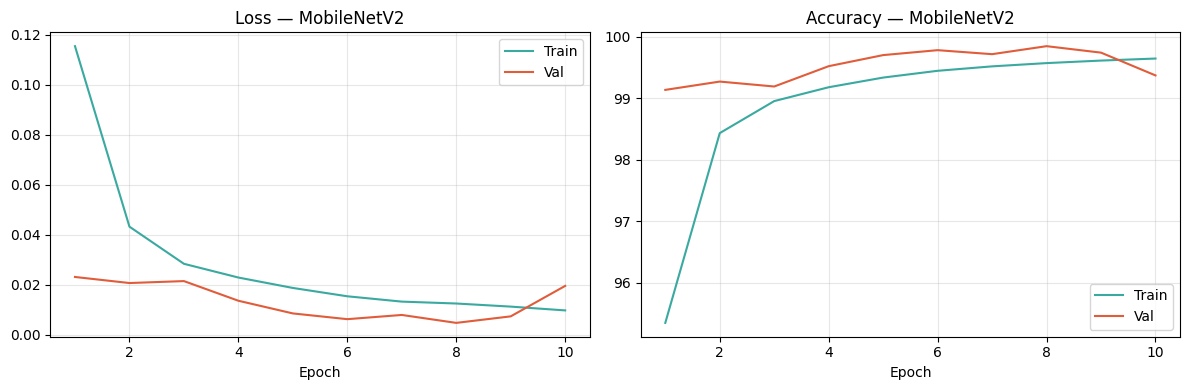

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS+1)

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#3AA99F')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#E05C3A')
axes[0].set_title(f'Loss — {MODEL_NAME}')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train', color='#3AA99F')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='#E05C3A')
axes[1].set_title(f'Accuracy — {MODEL_NAME}')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{save_dir}/learning_curves_{MODEL_NAME}.png')
plt.show()

## Cell 9 — Evaluation on Test Set

In [8]:
model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        out   = model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1]
        preds = out.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

acc = (all_preds == all_labels).mean() * 100
print(f'Test Accuracy: {acc:.2f}%')

Test Accuracy: 99.77%


## Cell 10 — Per-class Metrics (Precision, Recall, F1)

In [9]:
print(f'Classification Report — {MODEL_NAME}')
print('='*50)
print(classification_report(
    all_labels, all_preds,
    target_names=['FAKE', 'REAL'],
    digits=4
))

Classification Report — MobileNetV2
              precision    recall  f1-score   support

        FAKE     0.9963    0.9990    0.9977     10000
        REAL     0.9990    0.9963    0.9976     10000

    accuracy                         0.9977     20000
   macro avg     0.9977    0.9976    0.9976     20000
weighted avg     0.9977    0.9977    0.9976     20000



## Cell 11 — Confusion Matrix

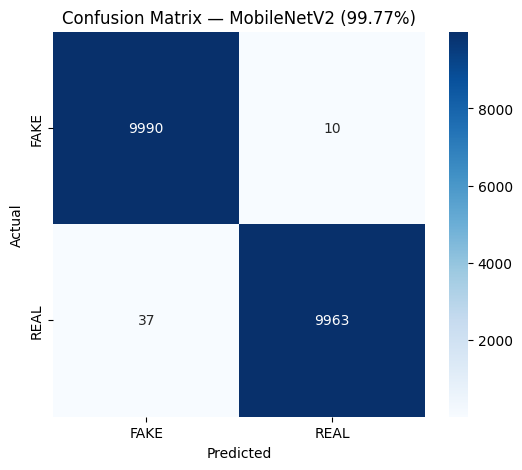

In [10]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'])
plt.title(f'Confusion Matrix — {MODEL_NAME} ({acc:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig(f'{save_dir}/confusion_matrix_{MODEL_NAME}.png')
plt.show()

## Cell 12 — ROC Curve

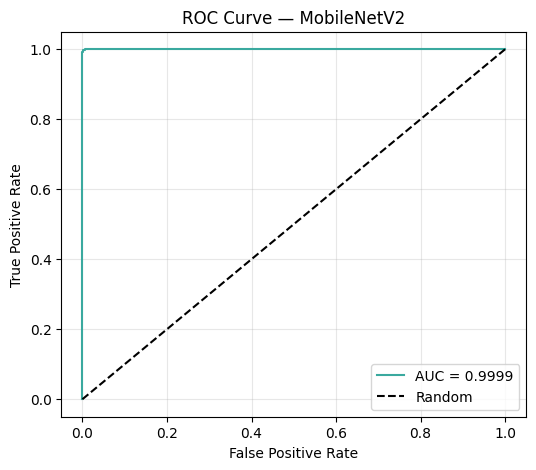

In [11]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#3AA99F', label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {MODEL_NAME}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{save_dir}/roc_{MODEL_NAME}.png')
plt.show()